In [1]:
using DelimitedFiles
using Plots
using NonlinearEigenproblems
using LinearAlgebra
using PyCall
include("BaseFlow_cavity.jl")


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


mode = 1:cavity; mode = 2:stationary; mode = 3:rotation;


In [ ]:
## aixal flow stability
py""" 
import numpy as np
from scipy.integrate import solve_bvp

kappa = 1 # 注意：在外部需确保 Ro 被正确解析传入
Ts = 0.1

def oneDiskODE(z, y):
    # Y0 = H, Y1 = F', Y2 = F, Y3 = G', Y4 = G
    dydz = np.zeros((5, len(z)))
    dydz[0] = -2.0 * y[2]
    dydz[1] = kappa * (y[2]**2 + y[0]*y[1] - (y[4]**2 - 1.0)) - (2.0 - kappa - kappa**2)*(y[4] - 1.0) + Ts**2
    dydz[2] = y[1]
    dydz[3] = kappa * (2.0*y[2]*y[4] + y[0]*y[3]) + (2.0 - kappa - kappa**2)*y[2]
    dydz[4] = y[3]
    return dydz 

def oneDiskBC(ya, yb):
    # 壁面 (z=0): H=0, F=0, G=0
    resa = np.array([ya[0], ya[2], ya[4]])
    # 远场 (z=30): F = -Ts, G = 1.0
    resb = np.array([yb[2] + Ts, yb[4] - 1.0])
    return np.concatenate((resa, resb))

# 【优化 1】减少初始网格点数，让求解器自己去自适应加密
z_init = np.linspace(0, 30, 500) 
y_guess = np.zeros((5, z_init.size))

# 【优化 2】构造满足边界条件的平滑初始场 (指数过渡)
# z=0时全为0; z无穷大时满足远场条件
y_guess[0, :] = 0.0                             # H: 初始简单设为0
y_guess[2, :] = -Ts * (1.0 - np.exp(-z_init))   # F: 从 0 过渡到 -Ts
y_guess[4, :] = 1.0 - np.exp(-z_init)           # G: 从 0 过渡到 1.0

# 导数项 F' 和 G' 也可以由上面的解析求导得到（有助于进一步加速收敛）
y_guess[1, :] = -Ts * np.exp(-z_init)           # F'
y_guess[3, :] = np.exp(-z_init)                 # G'

# 【优化 3】求解。如果 1e-10 难收敛，可以先用 1e-6 算一个粗解，再作为新猜测值代入
solution = solve_bvp(oneDiskODE, oneDiskBC, z_init, y_guess, tol=1e-10, max_nodes=100000)

# 求解完成后，在你需要的高密度网格上进行插值输出
x_plot = np.linspace(0, 30, 2000)

if solution.success:
    # solution.sol 自动处理了样条插值
    y1_plot = solution.sol(x_plot)[0]  # H
    y2_plot = solution.sol(x_plot)[2]  # F
    y3_plot = solution.sol(x_plot)[4]  # G
    y4_plot = solution.sol(x_plot)[1]  # F'
    y5_plot = solution.sol(x_plot)[3]  # G'
else:
    print("求解失败:", solution.message)
    """
    w0 = py"y1_plot"
    u0 = py"y2_plot"
    v0 = py"y3_plot"
    du0 = py"y4_plot"
    dv0 = py"y5_plot"
    z = py"x_plot";

In [40]:
py"""
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import math
from math import sqrt
Re_s = 1000
a = -0.2
def oneDiskODE(z,y):
        # # Y0 = H, Y1 = F,Y2 = F', Y3 = F'', Y4 = G, Y5 = G'
        dH = -2 * sqrt(Re_s) * y[1]
        dydz = np.zeros((6, len(z)))
        dydz = np.array([dH , y[2] , y[3] , Re_s * ( (1/sqrt(Re_s)) * ( y[3] * y[0] + y[2] * dH) - 2 * y[4] * y[5] + 2 * y[1] * y[2]) , y[5] , Re_s * ( (1/sqrt(Re_s)) * y[5] * y[0] + 2 * y[1] * y[4])])
        return dydz 

def oneDiskBC(ya, yb):
        resa = np.array([ya[0] + a,ya[1], ya[4] - 1])
        
        resb = np.array([yb[0],yb[1], yb[4] - 0])
        
        return np.concatenate((resa, resb))


z = np.linspace(0, 1, 100)
y = np.zeros((6, len(z)))
y_guess = np.zeros((6, z.size))
y_guess[0] = 0
y_guess[1] = 0
y_guess[2] = 0
y_guess[3] = 0
y_guess[4] = 1
y_guess[5] = 0
solution = solve_bvp(oneDiskODE, oneDiskBC, z, y_guess,max_nodes=5000000)

x_plot = np.linspace(0, 1, 2000)


y1_plot = solution.sol(x_plot)[0]
y2_plot = solution.sol(x_plot)[1]
y3_plot = solution.sol(x_plot)[4]
y4_plot = solution.sol(x_plot)[2]
y5_plot = solution.sol(x_plot)[5]
"""
w0 = py"y1_plot"
u0 = py"y2_plot"
v0 = py"y3_plot"
du0 = py"y4_plot"
dv0 = py"y5_plot"
z = py"x_plot"

2000-element Vector{Float64}:
 0.0
 0.0005002501250625312
 0.0010005002501250625
 0.0015007503751875936
 0.002001000500250125
 0.0025012506253126563
 0.003001500750375187
 0.0035017508754377185
 0.00400200100050025
 0.004502251125562781
 ⋮
 0.9959979989994997
 0.9964982491245622
 0.9969984992496247
 0.9974987493746873
 0.9979989994997498
 0.9984992496248123
 0.9989994997498749
 0.9994997498749374
 1.0

In [37]:
N_cheb = 129
mode = 1
D,D2,z = CRC_BF.Cheb(N_cheb,mode)
F,G,H = CRC_BF.interp(u0,v0,w0,z,N_cheb,mode)

([1.2525223876260883e-20; 0.0031957910287121047; … ; -0.0009016573697767025; -6.337394632238268e-19;;], [1.0; 0.9968266366784909; … ; 0.0007411790093677572; -5.864644368551962e-19;;], [0.2; 0.1999787809444144; … ; -5.982177870987472e-6; 1.0842021724855044e-19;;])

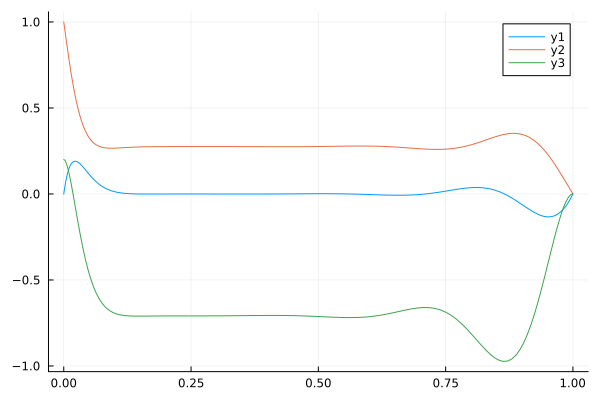

In [38]:
plot(z,F)
plot!(z,G)
plot!(z,H)

In [41]:
R = 278.6
be = 0.08
OMEGA = 2.19
omega = OMEGA/R
c = 0.3
Res = 1000
cof = Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2,Res)
L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega,R)
L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb,mode)
nep = PEP([L0,L1,L2]);
eigval,eigvec = iar(nep, σ = c, neigs = 3,maxit = 500 , tol=1e-14)
vel = eig_full(eigvec,N_cheb,1)
@show eigval

eigval = ComplexF64[0.35959732221502777 + 0.02822158709038847im, 0.26551443536376906 + 0.058170071961209276im, 0.3884416874070685 + 0.3310261058054667im]


3-element Vector{ComplexF64}:
 0.35959732221502777 + 0.02822158709038847im
 0.26551443536376906 + 0.058170071961209276im
  0.3884416874070685 + 0.3310261058054667im

In [30]:
struct COF
        Ta :: Matrix{ComplexF64}
        A :: Matrix{ComplexF64}
        B :: Matrix{ComplexF64}
        C :: Matrix{ComplexF64}
        dC :: Matrix{ComplexF64}
        D1 :: Matrix{ComplexF64}
        Vxx :: Matrix{ComplexF64}
        Vyy :: Matrix{ComplexF64}
        Vzz :: Matrix{ComplexF64}
        dVzz :: Matrix{ComplexF64}
        d2Vzz :: Matrix{ComplexF64}
        Vxy :: Matrix{ComplexF64}
        Vxz :: Matrix{ComplexF64}
        dVxz :: Matrix{ComplexF64}
        Vyz :: Matrix{ComplexF64}
        dVyz :: Matrix{ComplexF64}
end
function Spatial_mode_BEK1(F,G,H,R,N_cheb,D,D2,Res)
    Res0 = sqrt(Res)
    size = N_cheb + 1
    eye = I(N_cheb+1)
    Zero = zeros(N_cheb+1,N_cheb+1)
    Ta = zeros(4*size,4*size)
    A = zeros(4*size,4*size)
    B = zeros(4*size,4*size)
    C = zeros(4*size,4*size)
    D1 = zeros(4*size,4*size)
    Vxy = zeros(4*size,4*size)
    Vxz = zeros(4*size,4*size)
    Vyz = zeros(4*size,4*size)
    Vxx = zeros(4*size,4*size)
    Vyy = zeros(4*size,4*size)
    Vzz = zeros(4*size,4*size)
    dVxz = zeros(4*size,4*size)
    dVyz = zeros(4*size,4*size)
    Ta_11 = eye
    Ta_12 = Ta_13 = Ta_14 = Zero
    Ta_22 = eye
    Ta_21 = Ta_23 = Ta_24 = Zero
    Ta_33 = eye
    Ta_31 = Ta_32 = Ta_34 = Zero
    Ta_41 = Ta_42 = Ta_43 = Ta_44 = Zero

    A_11 = F .* eye
    A_12 = A_13 = Zero
    A_14 = eye
    A_22 = F .* eye
    A_21 = A_23 = A_24 = Zero
    A_31 = A_32 = A_34 = Zero
    A_33 = F .* eye
    A_41 = (1) .* eye
    A_42 = A_43 = A_44 = Zero

    B_11 = (1/R) * G .* eye
    B_12 = B_13 = B_14 = Zero
    B_21 = B_23 = Zero
    B_22 = (1/R) * G .* eye
    B_24 = (1/R) .* eye
    B_31 = B_32 = B_34 = Zero
    B_33 = (1/R) * G .* eye
    B_41 = B_43 = B_44 = Zero
    B_42 = (1/R) .* eye

    C_11 = (1/(R*Res0)) * H .* eye
    dC_11 = D * diag(C_11) .* eye
    C_12 = C_13 = C_14 = Zero
    dC_12 = dC_13 = dC_14 = Zero
    C_22 = (1/(R*Res0)) * H .* eye
    dC_22 = D * diag(C_22) .* eye
    C_21 = C_23 = C_24 = Zero
    dC_21 = dC_23 = dC_24 = Zero
    C_31 = C_32 = Zero
    dC_31 = dC_32 = Zero
    C_33 = (1/(R*Res0)) * H .* eye
    dC_33 = D * diag(C_33) .* eye
    C_34 = 1/Res0 * eye
    dC_34 = D * diag(C_34) .* eye
    C_41 = C_42 = C_44 = Zero
    dC_41 = dC_42 = dC_44 = Zero
    C_43 = (1/Res0) * eye
    dC_43 = D * diag(C_43) .* eye

    D_11 = (1/R) * F .* eye
    D_12 = -(1/R) * 2 * (G.+1) .* eye
    D_13 = 1/Res0 * D * F .* eye
    D_14 = Zero
    D_21 = (1/R) * 2 * (G.+1) .* eye
    D_22 = (1/R) * F .* eye
    D_23 = 1/Res0 * D * G .* eye
    D_24 = Zero
    D_31 = D_32 = D_34 = Zero
    D_33 = (1/(R*Res0)) * D*H.* eye
    D_41 = 1/R .* eye
    D_42 = D_43 = D_44 = Zero

    Vxx_11 = -(1/R) * eye
    Vxx_12 = Vxx_13 = Vxx_14 = Zero
    Vxx_22 = -(1/R) * eye
    Vxx_21 = Vxx_23 = Vxx_24 = Zero
    Vxx_33 = -(1/R) * eye
    Vxx_31 = Vxx_32 = Vxx_34 = Zero
    Vxx_41 = Vxx_42 = Vxx_43 = Vxx_44 = Zero

    Vyy_11 = -(1/R^3) * eye
    Vyy_12 = Vyy_13 = Vyy_14 = Zero
    Vyy_22 = -(1/R^3) * eye
    Vyy_21 = Vyy_23 = Vyy_24 = Zero
    Vyy_33 = -(1/R^3) * eye
    Vyy_31 = Vyy_32 = Vyy_34 = Zero
    Vyy_41 = Vyy_42 = Vyy_43 = Vyy_44 = Zero

    Vzz_11 = -(1/(R*Res)) * eye
    dVzz_11 = D * diag(Vzz_11) .* eye
    d2Vzz_11 = D2 * diag(Vzz_11) .* eye
    Vzz_12 = Vzz_13 = Vzz_14 = Zero
    dVzz_12 = dVzz_13 = dVzz_14 = Zero
    d2Vzz_12 = d2Vzz_13 = d2Vzz_14 = Zero
    Vzz_22 =  -(1/(R*Res)) * eye
    dVzz_22 = D * diag(Vzz_22) .* eye
    d2Vzz_22 = D2 * diag(Vzz_22) .* eye
    Vzz_21 = Vzz_23 = Vzz_24 = Zero
    dVzz_21 = dVzz_23 = dVzz_24 = Zero
    d2Vzz_21 = d2Vzz_23 = d2Vzz_24 = Zero
    Vzz_33 =  -(1/(R*Res)) * eye
    dVzz_33 = D * diag(Vzz_33) .* eye
    d2Vzz_33 = D2 * diag(Vzz_33) .* eye
    Vzz_31 = Vzz_32 = Vzz_34 = Zero
    dVzz_31 = dVzz_32 = dVzz_34 = Zero
    d2Vzz_31 = d2Vzz_32 = d2Vzz_34 = Zero
    Vzz_41 = Vzz_42 = Vzz_43 = Vzz_44 = Zero
    dVzz_41 = dVzz_42 = dVzz_43 = dVzz_44 = Zero
    d2Vzz_41 = d2Vzz_42 = d2Vzz_43 = d2Vzz_44 = Zero

    Vxy = zeros(4*size,4*size)
    dVxy = zeros(4*size,4*size)
    Vxz = zeros(4*size,4*size)
    Vyz = zeros(4*size,4*size)

    Ta = [Ta_11 Ta_12 Ta_13 Ta_14;Ta_21 Ta_22 Ta_23 Ta_24;Ta_31 Ta_32 Ta_33 Ta_34;Ta_41 Ta_42 Ta_43 Ta_44]
    A = [A_11 A_12 A_13 A_14;A_21 A_22 A_23 A_24;A_31 A_32 A_33 A_34;A_41 A_42 A_43 A_44]
    B = [B_11 B_12 B_13 B_14;B_21 B_22 B_23 B_24;B_31 B_32 B_33 B_34;B_41 B_42 B_43 B_44]
    C = [C_11 C_12 C_13 C_14;C_21 C_22 C_23 C_24;C_31 C_32 C_33 C_34;C_41 C_42 C_43 C_44]
    dC = [dC_11 dC_12 dC_13 dC_14;dC_21 dC_22 dC_23 dC_24;dC_31 dC_32 dC_33 dC_34;dC_41 dC_42 dC_43 dC_44]
    D1 = [D_11 D_12 D_13 D_14;D_21 D_22 D_23 D_24;D_31 D_32 D_33 D_34;D_41 D_42 D_43 D_44]
    Vxx = [Vxx_11 Vxx_12 Vxx_13 Vxx_14;Vxx_21 Vxx_22 Vxx_23 Vxx_24;Vxx_31 Vxx_32 Vxx_33 Vxx_34;Vxx_41 Vxx_42 Vxx_43 Vxx_44]
    Vyy = [Vyy_11 Vyy_12 Vyy_13 Vyy_14;Vyy_21 Vyy_22 Vyy_23 Vyy_24;Vyy_31 Vyy_32 Vyy_33 Vyy_34;Vyy_41 Vyy_42 Vyy_43 Vyy_44]
    Vzz = [Vzz_11 Vzz_12 Vzz_13 Vzz_14;Vzz_21 Vzz_22 Vzz_23 Vzz_24;Vzz_31 Vzz_32 Vzz_33 Vzz_34;Vzz_41 Vzz_42 Vzz_43 Vzz_44]
    dVzz = [dVzz_11 dVzz_12 dVzz_13 dVzz_14;dVzz_21 dVzz_22 dVzz_23 dVzz_24;dVzz_31 dVzz_32 dVzz_33 dVzz_34;dVzz_41 dVzz_42 dVzz_43 dVzz_44]
    d2Vzz = [d2Vzz_11 d2Vzz_12 d2Vzz_13 d2Vzz_14;d2Vzz_21 d2Vzz_22 d2Vzz_23 d2Vzz_24;d2Vzz_31 d2Vzz_32 d2Vzz_33 d2Vzz_34;d2Vzz_41 d2Vzz_42 d2Vzz_43 d2Vzz_44]
    return COF(Ta,A,B,C,dC,D1,Vxx,Vyy,Vzz,dVzz,d2Vzz,Vxy,Vxz,dVxz,Vyz,dVyz)
end
function Spatial_mode_BEK2(F,G,H,R,N_cheb,D,D2,Ro,Co)
    if Ro == -1
        Ro *= -1
    end
    size = N_cheb + 1
    eye = I(N_cheb+1)
    Zero = zeros(N_cheb+1,N_cheb+1)
    Ta = zeros(4*size,4*size)
    A = zeros(4*size,4*size)
    B = zeros(4*size,4*size)
    C = zeros(4*size,4*size)
    D1 = zeros(4*size,4*size)
    Vxy = zeros(4*size,4*size)
    Vxz = zeros(4*size,4*size)
    Vyz = zeros(4*size,4*size)
    Vxx = zeros(4*size,4*size)
    Vyy = zeros(4*size,4*size)
    Vzz = zeros(4*size,4*size)
    dVxz = zeros(4*size,4*size)
    dVyz = zeros(4*size,4*size)
    Ta_11 = eye
    Ta_12 = Ta_13 = Ta_14 = Zero
    Ta_22 = eye
    Ta_21 = Ta_23 = Ta_24 = Zero
    Ta_33 = eye
    Ta_31 = Ta_32 = Ta_34 = Zero
    Ta_41 = Ta_42 = Ta_43 = Ta_44 = Zero

    A_11 = F .* eye
    A_12 = A_13 = Zero
    A_14 = eye
    A_22 = F .* eye
    A_21 = A_23 = A_24 = Zero
    A_31 = A_32 = A_34 = Zero
    A_33 = F .* eye
    A_41 = eye
    A_42 = A_43 = A_44 = Zero

    B_11 = (1/R) * G .* eye
    B_12 = B_13 = B_14 = Zero
    B_21 = B_23 = Zero
    B_22 = (1/R) * G .* eye
    B_24 = (1/R) .* eye
    B_31 = B_32 = B_34 = Zero
    B_33 = (1/R) * G .* eye
    B_41 = B_43 = B_44 = Zero
    B_42 = (1/R) .* eye

    C_11 = (Ro/(R)) * H .* eye
    dC_11 = D * diag(C_11) .* eye
    C_12 = C_13 = C_14 = Zero
    dC_12 = dC_13 = dC_14 = Zero
    C_22 = (Ro/(R)) * H .* eye
    dC_22 = D * diag(C_22) .* eye
    C_21 = C_23 = C_24 = Zero
    dC_21 = dC_23 = dC_24 = Zero
    C_31 = C_32 = Zero
    dC_31 = dC_32 = Zero
    C_33 = (Ro/(R)) * H .* eye
    dC_33 = D * diag(C_33) .* eye
    C_34 = 1 * eye
    dC_34 = D * diag(C_34) .* eye
    C_41 = C_42 = C_44 = Zero
    dC_41 = dC_42 = dC_44 = Zero
    C_43 = (1) * eye
    dC_43 = D * diag(C_43) .* eye

    D_11 = (Ro/R) * F .* eye
    D_12 = -(1/R) * (2*Ro*G.+ Co) .* eye
    D_13 = D * F .* eye
    D_14 = Zero
    D_21 = (1/R) * (2*Ro*G.+ Co) .* eye
    D_22 = (Ro/R) * F .* eye
    D_23 = D * G .* eye
    D_24 = Zero
    D_31 = D_32 = D_34 = Zero
    D_33 = (Ro/(R)) * D*H.* eye
    D_41 = Ro/R .* eye
    D_42 = D_43 = D_44 = Zero

    Vxx_11 = -(1/R) * eye
    Vxx_12 = Vxx_13 = Vxx_14 = Zero
    Vxx_22 = -(1/R) * eye
    Vxx_21 = Vxx_23 = Vxx_24 = Zero
    Vxx_33 = -(1/R) * eye
    Vxx_31 = Vxx_32 = Vxx_34 = Zero
    Vxx_41 = Vxx_42 = Vxx_43 = Vxx_44 = Zero

    Vyy_11 = -(1/R^3) * eye
    Vyy_12 = Vyy_13 = Vyy_14 = Zero
    Vyy_22 = -(1/R^3) * eye
    Vyy_21 = Vyy_23 = Vyy_24 = Zero
    Vyy_33 = -(1/R^3) * eye
    Vyy_31 = Vyy_32 = Vyy_34 = Zero
    Vyy_41 = Vyy_42 = Vyy_43 = Vyy_44 = Zero

    Vzz_11 = -(1/(R)) * eye
    dVzz_11 = D * diag(Vzz_11) .* eye
    d2Vzz_11 = D2 * diag(Vzz_11) .* eye
    Vzz_12 = Vzz_13 = Vzz_14 = Zero
    dVzz_12 = dVzz_13 = dVzz_14 = Zero
    d2Vzz_12 = d2Vzz_13 = d2Vzz_14 = Zero
    Vzz_22 =  -(1/(R)) * eye
    dVzz_22 = D * diag(Vzz_22) .* eye
    d2Vzz_22 = D2 * diag(Vzz_22) .* eye
    Vzz_21 = Vzz_23 = Vzz_24 = Zero
    dVzz_21 = dVzz_23 = dVzz_24 = Zero
    d2Vzz_21 = d2Vzz_23 = d2Vzz_24 = Zero
    Vzz_33 =  -(1/(R)) * eye
    dVzz_33 = D * diag(Vzz_33) .* eye
    d2Vzz_33 = D2 * diag(Vzz_33) .* eye
    Vzz_31 = Vzz_32 = Vzz_34 = Zero
    dVzz_31 = dVzz_32 = dVzz_34 = Zero
    d2Vzz_31 = d2Vzz_32 = d2Vzz_34 = Zero
    Vzz_41 = Vzz_42 = Vzz_43 = Vzz_44 = Zero
    dVzz_41 = dVzz_42 = dVzz_43 = dVzz_44 = Zero
    d2Vzz_41 = d2Vzz_42 = d2Vzz_43 = d2Vzz_44 = Zero

    Vxy = zeros(4*size,4*size)
    Vxz = zeros(4*size,4*size)
    Vyz = zeros(4*size,4*size)

    Ta = [Ta_11 Ta_12 Ta_13 Ta_14;Ta_21 Ta_22 Ta_23 Ta_24;Ta_31 Ta_32 Ta_33 Ta_34;Ta_41 Ta_42 Ta_43 Ta_44]
    A = [A_11 A_12 A_13 A_14;A_21 A_22 A_23 A_24;A_31 A_32 A_33 A_34;A_41 A_42 A_43 A_44]
    B = [B_11 B_12 B_13 B_14;B_21 B_22 B_23 B_24;B_31 B_32 B_33 B_34;B_41 B_42 B_43 B_44]
    C = [C_11 C_12 C_13 C_14;C_21 C_22 C_23 C_24;C_31 C_32 C_33 C_34;C_41 C_42 C_43 C_44]
    dC = [dC_11 dC_12 dC_13 dC_14;dC_21 dC_22 dC_23 dC_24;dC_31 dC_32 dC_33 dC_34;dC_41 dC_42 dC_43 dC_44]
    D1 = [D_11 D_12 D_13 D_14;D_21 D_22 D_23 D_24;D_31 D_32 D_33 D_34;D_41 D_42 D_43 D_44]
    Vxx = [Vxx_11 Vxx_12 Vxx_13 Vxx_14;Vxx_21 Vxx_22 Vxx_23 Vxx_24;Vxx_31 Vxx_32 Vxx_33 Vxx_34;Vxx_41 Vxx_42 Vxx_43 Vxx_44]
    Vyy = [Vyy_11 Vyy_12 Vyy_13 Vyy_14;Vyy_21 Vyy_22 Vyy_23 Vyy_24;Vyy_31 Vyy_32 Vyy_33 Vyy_34;Vyy_41 Vyy_42 Vyy_43 Vyy_44]
    Vzz = [Vzz_11 Vzz_12 Vzz_13 Vzz_14;Vzz_21 Vzz_22 Vzz_23 Vzz_24;Vzz_31 Vzz_32 Vzz_33 Vzz_34;Vzz_41 Vzz_42 Vzz_43 Vzz_44]
    dVzz = [dVzz_11 dVzz_12 dVzz_13 dVzz_14;dVzz_21 dVzz_22 dVzz_23 dVzz_24;dVzz_31 dVzz_32 dVzz_33 dVzz_34;dVzz_41 dVzz_42 dVzz_43 dVzz_44]
    d2Vzz = [d2Vzz_11 d2Vzz_12 d2Vzz_13 d2Vzz_14;d2Vzz_21 d2Vzz_22 d2Vzz_23 d2Vzz_24;d2Vzz_31 d2Vzz_32 d2Vzz_33 d2Vzz_34;d2Vzz_41 d2Vzz_42 d2Vzz_43 d2Vzz_44]
    return COF(Ta,A,B,C,dC,D1,Vxx,Vyy,Vzz,dVzz,d2Vzz,Vxy,Vxz,dVxz,Vyz,dVyz)
end
function assemble_mat(cof,D,D2,be,omega,R)
    L0 = cof.D1  + im * R * be * cof.B - im * omega * cof.Ta - be^2 * R^2 * cof.Vyy + (cof.C .+ im * be * R * cof.Vyz) * kron(I(4), D)  + (cof.Vzz) * kron(I(4),D2) 
    L1 = im * cof.A - be * R * cof.Vxy + im *  cof.Vxz * kron(I(4),D)
    L2 = -cof.Vxx 
    return L0,L1,L2
end
function assemble_adjmat(cof,D,D2,be,omega,R)
    A0_raw = transpose(cof.D1) + (im * R * be * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * R^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * R * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(4),D) + transpose(cof.Vzz) * kron(I(4),D2)
    A1_raw = (im * transpose(cof.A)) - (be * R * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(4),D) 
    A2_raw = -transpose(cof.Vxx)
    return A0_raw,A1_raw,A2_raw
end
function boudary_condition(L0,L1,L2,N_cheb,mode)
    if mode == 1 
        L0 = L0[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3))]
        L1 = L1[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3))]
        L2 = L2[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3))]
    elseif mode == 3
        L0 = L0[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4))]
        L1 = L1[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4))]
        L2 = L2[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4))]
    end
    return L0,L1,L2
end
function eig_full(eigvec,N_cheb,num)
    N = N_cheb + 1
    eigvec = eigvec[:,num]
    insert!(eigvec,4N-8,0im)
    insert!(eigvec,3N-5,0im)
    insert!(eigvec,3N-5,0im)
    insert!(eigvec,2N-3,0im)
    insert!(eigvec,2N-3,0im)
    insert!(eigvec,N-1,0im)
    insert!(eigvec,N-1,0im)
    insert!(eigvec,1,0im)
    u = eigvec[1:N]
    v = eigvec[N+1:2N]
    w = eigvec[2N+1:3N]
    p = eigvec[3N+1:4N]
    return (u,v,w,p)
end

eig_full (generic function with 1 method)